Cameras rendered.


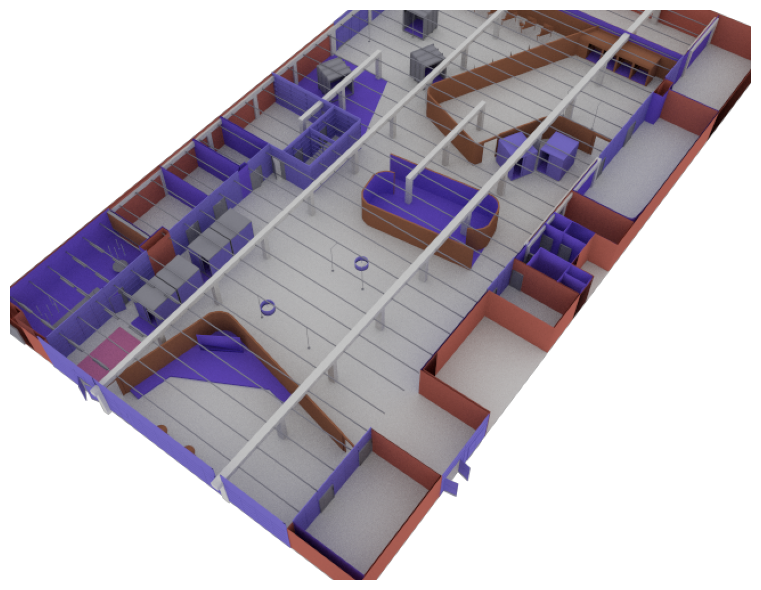

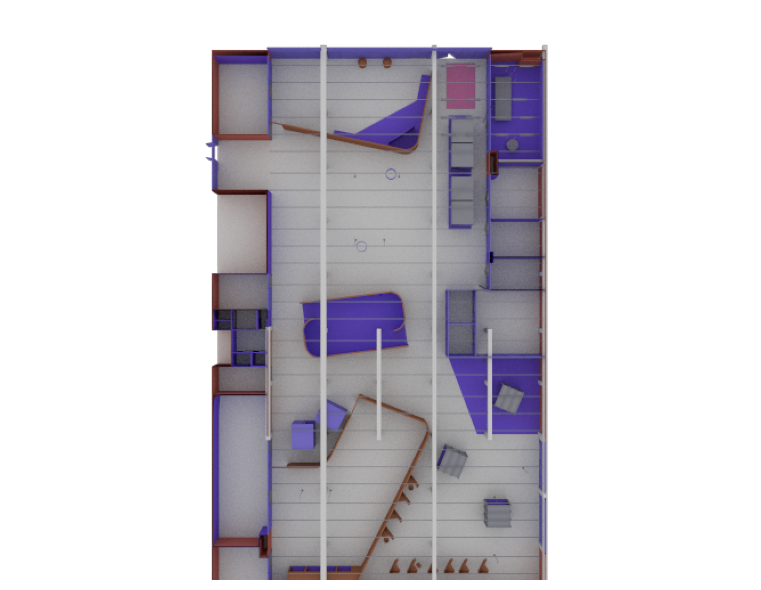

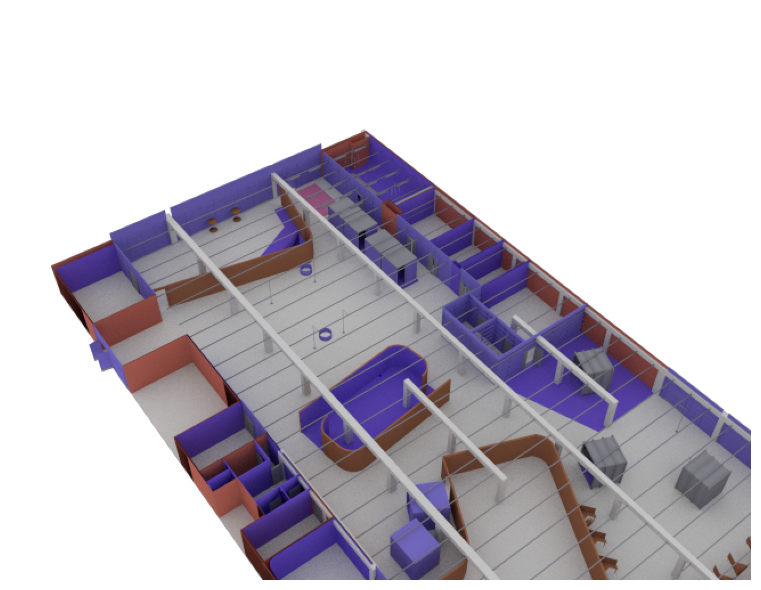

In [ ]:

import sionna.rt
import os
import mitsuba as mi
import time
import matplotlib.pyplot as plt
import numpy as np
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,PathSolver, RadioMapSolver, subcarrier_frequencies, ITURadioMaterial, SceneObject
from sionna.phy.channel import subcarrier_frequencies , cir_to_ofdm_channel
from geometry_msgs.msg import Point

scene = load_scene("/home/icon-group/catkin_ws/src/gz_sionna/gz_sionna/models/with_materials/untitled.xml") 
car_path = "/home/icon-group/catkin_ws/src/gz_sionna/gz_sionna/models/jetbot_real/jet.obj"
cube_path = "/home/icon-group/catkin_ws/src/gz_sionna/gz_sionna/models/jepa_objects/cube.obj"
ball_path = "/home/icon-group/catkin_ws/src/gz_sionna/gz_sionna/models/jepa_objects/ball.obj"
cylinder_path = "/home/icon-group/catkin_ws/src/gz_sionna/gz_sionna/models/jepa_objects/cylinder.obj"


no_preview = False
robot1_pos = Point(0,0,0)
robot1_orien = Point(0,0,0)

cube_material = ITURadioMaterial(
"cube-material",
"concrete",
thickness=1,
color=(1, 1, 0)
)

ball_material = ITURadioMaterial(
    "ball-material",
    "metal",
    thickness=1,
    color=(0, 1, 1)
)

cylinder_material = ITURadioMaterial(
    "cylinder-material",
    "wood",
    thickness=1,
    color=(1, 0, 1)
)


cube_positions = [
    (7.809810,  8.423260, 0.5),
    (2.814624,  0.555732, 0.5),
    (10.178213, 7.527594, 0.5),
    (4.503686, -8.171050, 0.5),
    (-10.628513, 3.182821, 0.5),
    (-1.856461, 8.704827, 0.5),
    (-7.197225, -6.432545, 0.5),
    (-11.255310, -4.816126, 0.5),
]

ball_positions = [
    (1.683725,  8.405119, 0.5),
    (8.686228, -2.047810, 0.5),
    (9.244602, 10.747196, 0.5),
    (2.328079, -8.332348, 0.5),
    (-10.061080, -8.313878, 0.5),
    (7.762015,  3.934394, 0.5),
    (6.192001, -7.197225, 0.5),
    (-10.707787, 8.113759, 0.5),
]

cylinder_positions = [
    (2.323899,  2.778099, 0.5),
    (2.411660, -2.047805, 0.5),
    (9.274621,  1.227368, 0.5),
    (-11.150761, -2.211683, 0.5),
    (-11.712104,  9.665686, 0.5),
    (10.670957, -5.428221, 0.5),
    (-8.323398, -8.323398, 0.5),
    (-10.486228, 11.339570, 0.5),
]


num_ball = 8
balls = [SceneObject(fname=ball_path , 
                name=f"ball-{i}",
                radio_material=ball_material)
    for i in range(num_ball)]

num_cubes = 8
cubes = [SceneObject(fname=cube_path , 
                name=f"cube-{i}",
                radio_material=cube_material)
    for i in range(num_cubes)]


num_cylinder = 8
cylinders = [SceneObject(fname=cylinder_path , 
                name=f"cylinder-{i}",
                radio_material=cylinder_material)
    for i in range(num_cylinder)]



# scene.edit(add=balls)
# scene.edit(add=cubes)
# scene.edit(add=cylinders)

# for cube, pos in zip(cubes, cube_positions):
#     cube.position = mi.Point3f(*pos)

# for ball, pos in zip(balls, ball_positions):
#     ball.position = mi.Point3f(*pos)

# for cyl, pos in zip(cylinders, cylinder_positions):
#     cyl.position = mi.Point3f(*pos)


num_cars = 1
car_material = ITURadioMaterial("car-material",
                            "metal",
                            thickness=0.0001,
                            color=(0, 0, 1))

cars = [SceneObject(fname=car_path ,   #sionna.rt.scene.low_poly_car, # Simple mesh of a car
                name=f"car-{i}",
                radio_material=car_material)
    for i in range(num_cars)]

scene.edit(add=cars)

i = 0
my_cam = Camera(position=[40,30,60], look_at=[0,0,-10])
scene.render(camera=my_cam, resolution=[650, 500], num_samples=512);
my_cam2 = Camera(position=[0,0,100], look_at=[0,0,0])
scene.render(camera=my_cam2, resolution=[650, 500], num_samples=512);
my_cam3 = Camera(position=[-40,30,60], look_at=[0,0,10])
scene.render(camera=my_cam3, resolution=[650, 500], num_samples=512);
print("Cameras rendered.")

scene.tx_array = PlanarArray(
    num_rows=2,
    num_cols=4,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V",
)
scene.rx_array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso",
    polarization="V",
)


tx = Transmitter("tx", position= [robot1_pos.x, robot1_pos.y, robot1_pos.z],display_radius=0.1)

# rx1 = Receiver("rx_1", position=[11.561232 ,12.377551 ,6.837],display_radius=1)
# rx2 = Receiver("rx_2", position=[-11.283523,-5.880425,  6.837],display_radius=1) 
# rx3 = Receiver("rx_3", position=[-9.654398, 11.918360, 6.837],display_radius=1)

# # rx4 = Receiver("rx_4", position=[10.028879,-5.885381, 6.837],display_radius=0.1)
# # rx5 = Receiver("rx_5", position=[-1.3,2.5,  6.837],display_radius=0.1)

rx1 = Receiver("rx_1", position=[26.627333, 6.138611 , 6.837],display_radius=1)  
rx2 = Receiver("rx_2", position=[-32.122665, 11.765728, 6.837 ],display_radius=1) 
rx3 = Receiver("rx_3", position=[-32.122665, -7.217361,  6.837 ],display_radius=1)  
# rx5 = Receiver("rx_5", position=[-4.008763 ,0.092765 ,3.274808 ],display_radius=0.1) 

# scene.add(tx)
# scene.add(rx1)
# scene.add(rx2)
# scene.add(rx3)
# scene.add(rx4)
# scene.add(rx5)

scene.frequency = 2.14e9
scene.synthetic_array = True
subcarrier_spacing = 20e6 / 16  # 15e3
fft_size = 16
frequencies = subcarrier_frequencies(fft_size, subcarrier_spacing)

channels = []

# rm_solver = RadioMapSolver()
# p_solver = PathSolver()
path_solver = PathSolver()

USE_MONTE_CARLO = False  # GPU machine
tx.look_at(rx1) 
tx.look_at(rx2) 
tx.look_at(rx3)

In [8]:
scene.render_to_file(camera=my_cam,
                                filename="img2.png",
                                resolution=[650,500]); 

In [2]:
if not no_preview:
    scene.preview();

In [1]:
import sionna.rt
import os
import matplotlib.pyplot as plt
import numpy as np
import mitsuba as mi


no_preview = False # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies, ITURadioMaterial, SceneObject

In [2]:
# scene = load_scene("/home/icon-group/Documents/Josh/sionna/Tellus/sionna_test/withtop/untitled.xml") # Try also sionna.rt.scene.etoile
scene = load_scene("/home/icon-group/Documents/Josh/sionna/Tellus/sionna_test/with_materials/untitled.xml") 
car_path = "/home/icon-group/Documents/Josh/sionna/Tellus/sionna_test/jetbot_real/jet.obj"




In [3]:
    cube_path = "/home/icon-group/Documents/Josh/sionna/Tellus/sionna_test/jepa_objects/cube.obj"
    ball_path = "/home/icon-group/Documents/Josh/sionna/Tellus/sionna_test/jepa_objects/ball.obj"
    cylinder_path = "/home/icon-group/Documents/Josh/sionna/Tellus/sionna_test/jepa_objects/cylinder.obj"

    cube_material = ITURadioMaterial(
    "cube-material",
    "concrete",
    thickness=1,
    color=(1, 1, 0)
    )

    ball_material = ITURadioMaterial(
        "ball-material",
        "metal",
        thickness=1,
        color=(0, 1, 1)
    )

    cylinder_material = ITURadioMaterial(
        "cylinder-material",
        "wood",
        thickness=1,
        color=(1, 0, 1)
    )


    cube_positions = [
        (7.809810,  8.423260, 0.5),
        (2.814624,  0.555732, 0.5),
        (10.178213, 7.527594, 0.5),
        (4.503686, -8.171050, 0.5),
        (-10.628513, 3.182821, 0.5),
        (-1.856461, 8.704827, 0.5),
        (-7.197225, -6.432545, 0.5),
        (-11.255310, -4.816126, 0.5),
    ]

    ball_positions = [
        (1.683725,  8.405119, 0.5),
        (8.686228, -2.047810, 0.5),
        (9.244602, 10.747196, 0.5),
        (2.328079, -8.332348, 0.5),
        (-10.061080, -8.313878, 0.5),
        (7.762015,  3.934394, 0.5),
        (6.192001, -7.197225, 0.5),
        (-10.707787, 8.113759, 0.5),
    ]

    cylinder_positions = [
        (2.323899,  2.778099, 0.5),
        (2.411660, -2.047805, 0.5),
        (9.274621,  1.227368, 0.5),
        (-11.150761, -2.211683, 0.5),
        (-11.712104,  9.665686, 0.5),
        (10.670957, -5.428221, 0.5),
        (-8.323398, -8.323398, 0.5),
        (-10.486228, 11.339570, 0.5),
    ]


    num_ball = 8
    balls = [SceneObject(fname=ball_path , 
                    name=f"ball-{i}",
                    radio_material=ball_material)
        for i in range(num_ball)]
    
    num_cubes = 8
    cubes = [SceneObject(fname=cube_path , 
                    name=f"cube-{i}",
                    radio_material=cube_material)
        for i in range(num_cubes)]


    num_cylinder = 8
    cylinders = [SceneObject(fname=cylinder_path , 
                    name=f"cylinder-{i}",
                    radio_material=cylinder_material)
        for i in range(num_cylinder)]
    


    scene.edit(add=balls)
    scene.edit(add=cubes)
    scene.edit(add=cylinders)

    for cube, pos in zip(cubes, cube_positions):
        cube.position = mi.Point3f(*pos)

    for ball, pos in zip(balls, ball_positions):
        ball.position = mi.Point3f(*pos)

    for cyl, pos in zip(cylinders, cylinder_positions):
        cyl.position = mi.Point3f(*pos)


In [ ]:
if not no_preview:
    scene.preview();

In [4]:
num_cars = 1
car_material = ITURadioMaterial("car-material",
                            "metal",
                            thickness=1000,
                            color=(0, 0, 1))

cars = [SceneObject(fname=car_path ,   #sionna.rt.scene.low_poly_car, # Simple mesh of a car
                name=f"car-{i}",
                radio_material=car_material)
    for i in range(num_cars)]

scene.edit(add=cars)
cars[0].position = mi.Point3f(7.809810,8.423260,0.5)

In [5]:
if not no_preview:
    scene.preview();
    

In [20]:

# Configure antenna array for all transmitters
scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

# Configure antenna array for all receivers
scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="dipole",
                             polarization="cross")

# Create transmitter
tx = Transmitter(name="tx",
                 position=[0,0,5],
                 display_radius=0.6)

# Add transmitter instance to scene
scene.add(tx)

# Create a receiver
rx = Receiver(name="rx",
              position=[5.1, 0,0.09],
              display_radius=0.2)

# Add receiver instance to scene
scene.add(rx)

tx.look_at(rx) # Transmitter points towards receiver

In [21]:
# Instantiate a path solver
# The same path solver can be used with multiple scenes
p_solver  = PathSolver()

# Compute propagation paths
paths = p_solver(scene=scene,
                 max_depth=5,
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)

In [22]:
if no_preview:
    scene.render(camera=my_cam, paths=paths, clip_at=20);
else:
    scene.preview(paths=paths, clip_at=20);

In [23]:
a, tau = paths.cir(normalize_delays=True, out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of a: ", a.shape)

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
print("Shape of tau: ", tau.shape)

Shape of a:  (1, 2, 1, 1, 13, 1)
Shape of tau:  (1, 2, 1, 1, 13)


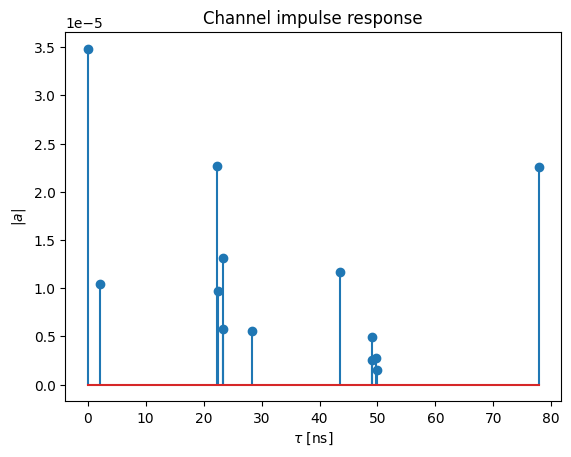

In [24]:
t = tau[0,0,0,0,:]/1e-9 # Scale to ns
a_abs = np.abs(a)[0,0,0,0,:,0]
a_max = np.max(a_abs)

# And plot the CIR
plt.figure()
plt.title("Channel impulse response")
plt.stem(t, a_abs)
plt.xlabel(r"$\tau$ [ns]")
plt.ylabel(r"$|a|$");

Shape of h_freq:  (1, 2, 1, 1, 1, 1024)


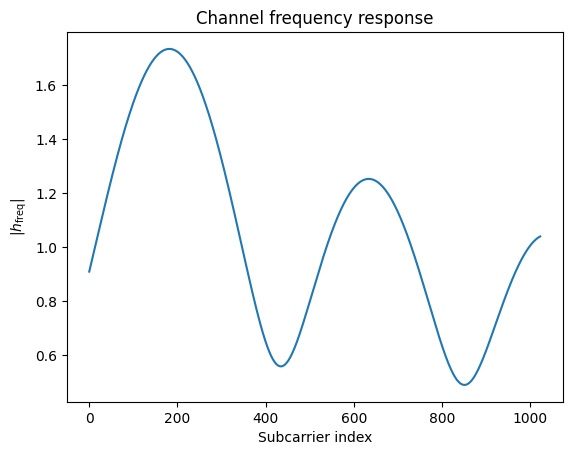

In [25]:
# OFDM system parameters
num_subcarriers = 1024
subcarrier_spacing=30e3

# Compute frequencies of subcarriers relative to the carrier frequency
frequencies = subcarrier_frequencies(num_subcarriers, subcarrier_spacing)

# Compute channel frequency response
h_freq = paths.cfr(frequencies=frequencies,
                   normalize=True, # Normalize energy
                   normalize_delays=True,
                   out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_time_steps, num_subcarriers]
print("Shape of h_freq: ", h_freq.shape)

# Plot absolute value
plt.figure()
plt.plot(np.abs(h_freq)[0,0,0,0,0,:]);
plt.xlabel("Subcarrier index");
plt.ylabel(r"|$h_\text{freq}$|");
plt.title("Channel frequency response");

Shape of taps:  (1, 2, 1, 1, 1, 107)


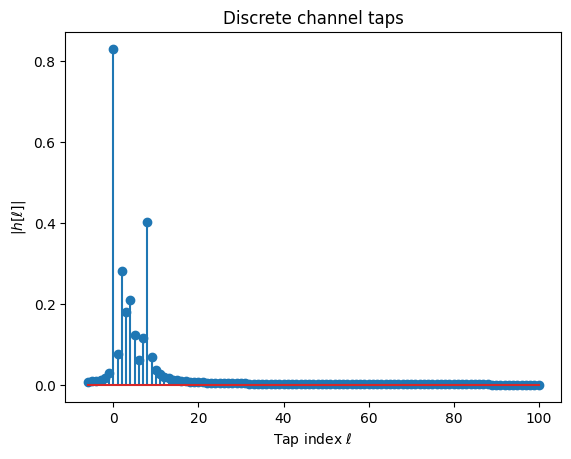

In [26]:
taps = paths.taps(bandwidth=100e6, # Bandwidth to which the channel is low-pass filtered
                  l_min=-6,        # Smallest time lag
                  l_max=100,       # Largest time lag
                  sampling_frequency=None, # Sampling at Nyquist rate, i.e., 1/bandwidth
                  normalize=True,  # Normalize energy
                  normalize_delays=True,
                  out_type="numpy")
print("Shape of taps: ", taps.shape)

plt.figure()
plt.stem(np.arange(-6, 101), np.abs(taps)[0,0,0,0,0]);
plt.xlabel(r"Tap index $\ell$");
plt.ylabel(r"|$h[\ell]|$");
plt.title("Discrete channel taps");

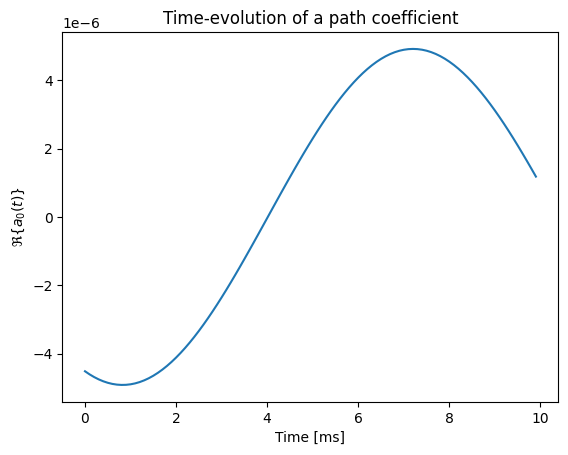

In [27]:
scene.get("tx").velocity = [10, 0, 0]

# Recompute propagation paths
paths_mob = p_solver(scene=scene,
                     max_depth=5,
                     los=True,
                     specular_reflection=True,
                     diffuse_reflection=False,
                     refraction=True,
                     synthetic_array=True,
                     seed=41)

# Compute CIR with time-evolution
num_time_steps=100
sampling_frequency = 1e4
a_mob, _ = paths_mob.cir(sampling_frequency=sampling_frequency,
                         num_time_steps=num_time_steps,
                         out_type="numpy")

# Inspect time-evolution of a single path coefficient
plt.figure()
plt.plot(np.arange(num_time_steps)/sampling_frequency*1000,
         a_mob[0,0,0,0,0].real);
plt.xlabel("Time [ms]");
plt.ylabel(r"$\Re\{a_0(t) \}$");
plt.title("Time-evolution of a path coefficient");

In [28]:
rm_solver = RadioMapSolver()

rm = rm_solver(scene=scene,
               max_depth=5,
               cell_size=[1,1],
               samples_per_tx=10**6)

In [29]:
if no_preview:
    scene.render(camera=my_cam, radio_map=rm);
else:
    scene.preview(radio_map=rm);